# Data Visualization & Storytelling
## Section 5.6 End-to-End Case Study
**Dataset:** Titanic Passengers  
**Source:** [Seaborn built-in](https://www.kaggle.com/c/titanic)  
**Student:** Dinesh Basnet  
**Date:** 2025  
**Course:** Data Science with Python

---

## Section 1-- Introduction & Dataset Overview

### Research Questions
1. What was the overall survival rate aboard the Titanic?
2. Did gender influence a passenger's chance of survival?
3. Did passenger class (socioeconomic status) affect survival outcomes?
4. How did age and fare correlate with survival?
5. What combination of factors most strongly predicted survival?

### Dataset Description
The Titanic dataset contains records for **891 passengers** aboard the RMS Titanic, which sank on 15 April 1912 after colliding with an iceberg. Each row represents one passenger and includes the following columns:

| Column | Description |
|--------|-------------|
| PassengerId | Unique identifier |
| Survived | 0 = No, 1 = Yes |
| Pclass | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Sex | Gender of passenger |
| Age | Age in years |
| SibSp | No. of siblings/spouses aboard |
| Parch | No. of parents/children aboard |
| Fare | Passenger fare paid (GBP) |
| Embarked | Port of embarkation (C=Cherbourg, Q=Queenstown, S=Southampton) |

## Section 2 — Data Loading & Cleaning

In [89]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
df = sns.load_dataset('titanic')
# df = pd.read_csv('titanic.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [43]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [44]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nMissing value percentage:')
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing value percentage:
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64


In [45]:

# Handle Missing Values
# Fill Age with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill Fare with median
df['fare'] = df['fare'].fillna(df['fare'].median())

# Drop rows where Embarked is missing
df.dropna(subset=['embark_town'], inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())
print(f'\nFinal dataset shape: {df.shape}')

Missing values after cleaning:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

Final dataset shape: (889, 15)


**Data Cleaning Notes:**  
The dataset had 177 missing Age values (19.9%) and 2 missing Embarked values. Age was imputed using the median (28 years) to preserve the sample size without introducing bias from mean imputation, which is sensitive to outliers. Fare had a single missing value filled with the median. The 2 rows with missing embarkation ports were dropped as they represent less than 0.3% of data and embarkation is a useful categorical variable.

## Section 3 — Matplotlib Visualizations
### Chart 1 — Bar Chart: Overall Survival Count

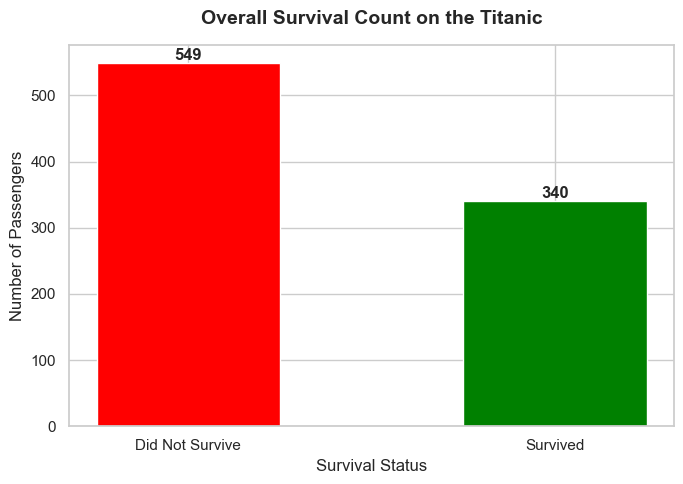

In [52]:
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(7, 5))
survival_counts = df['survived'].value_counts().sort_index()
colors = ['red', 'green']
bars = ax.bar(['Did Not Survive', 'Survived'], survival_counts.values, color=colors, width=0.5, edgecolor='white')

ax.set_title('Overall Survival Count on the Titanic', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Survival Status', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_survival_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Out of 891 passengers, only 340 (38.4%) survived the disaster. This stark imbalance reflects the chaotic and inadequate evacuation process. The 'women and children first' protocol and limited lifeboat capacity (enough for roughly half the passengers) directly explain this ratio.

### Chart 2-- Histogram: Age Distribution by Survival

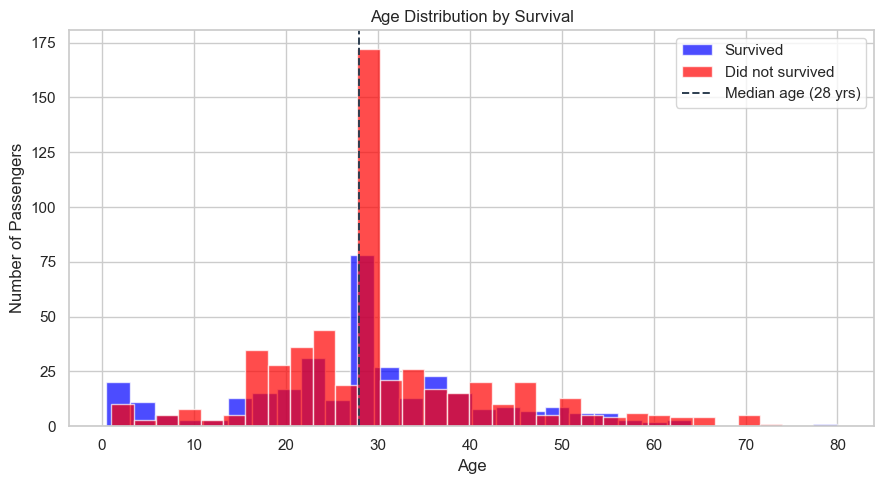

In [77]:
fig, ax = plt.subplots(figsize=(9,5))

ax.hist(df[df['survived'] == 1]['age'],bins=30,color='blue',alpha = 0.7,label="Survived")
ax.hist(df[df['survived'] == 0]['age'],bins=30,color='red',alpha = 0.7,label="Did not survived")

median_age = df['age'].median()
ax.axvline(
    median_age, color='#2c3e50', linestyle='--',
    linewidth=1.4, label=f'Median age ({median_age:.0f} yrs)'
)

ax.set_title("Age Distribution by Survival")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Passengers")
ax.legend()

plt.tight_layout()
plt.savefig('chart2_age_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The age distribution shows that young children (under 10) had relatively higher survival rates compared to adults, consistent with the evacuation priority given to children. The peak passenger age was in the 20–35 range. Older passengers (60+) had lower survival counts, potentially due to reduced mobility during the evacuation.

### Chart 3 -- Line Chart: Rolling Average Fare Over Passengers

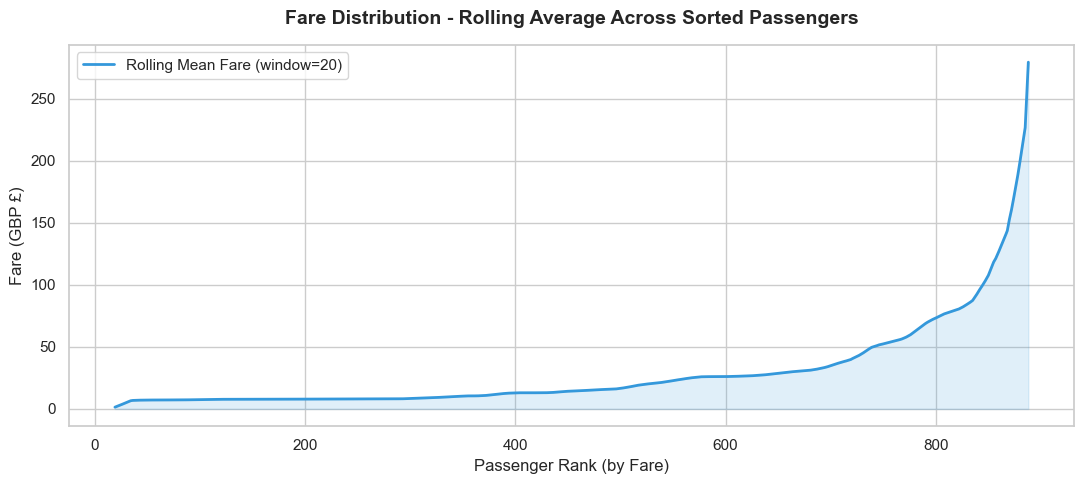

In [80]:
fig, ax = plt.subplots(figsize=(11, 5))

df_sorted = df.sort_values('fare').reset_index(drop=True)
ax.plot(df_sorted.index, df_sorted['fare'].rolling(20).mean(),
        color='#3498db', linewidth=2, label='Rolling Mean Fare (window=20)')
ax.fill_between(df_sorted.index, df_sorted['fare'].rolling(20).mean(),
                alpha=0.15, color='#3498db')

ax.set_title('Fare Distribution - Rolling Average Across Sorted Passengers', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Passenger Rank (by Fare)', fontsize=12)
ax.set_ylabel('Fare (GBP £)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart3_fare_line.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The fare distribution is heavily right-skewed with a long tail. The vast majority of passengers paid under £50, while a small elite paid fares exceeding £200–£500 for luxury cabin suites. This mirrors the strong class stratification aboard the Titanic — first-class passengers paid up to 10x the fare of third-class passengers.

### Chart 4-- Scatter Plot: Age vs Fare coloured by Survival

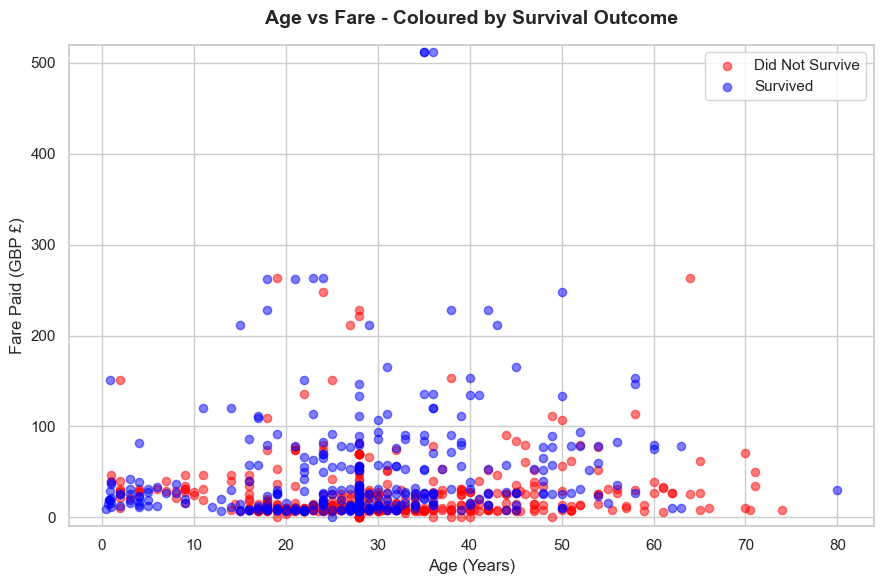

In [82]:
fig, ax = plt.subplots(figsize=(9, 6))

for survived, color, label in [(0,'red','Did Not Survive'),(1,'blue','Survived')]:
    subset = df[df['survived']==survived]
    ax.scatter(subset['age'], subset['fare'], c=color, alpha=0.5, s=35, label=label)

ax.set_title('Age vs Fare - Coloured by Survival Outcome', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age (Years)', fontsize=12)
ax.set_ylabel('Fare Paid (GBP £)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(-10, 520)

plt.tight_layout()
plt.savefig('chart4_age_fare_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Survivors (blue) are noticeably concentrated in the upper portion of the fare range, confirming that higher fare (a proxy for class and cabin location) correlates with survival. Lower-fare passengers crowd the bottom of the chart and show a higher proportion of non-survivors. Age alone does not strongly differentiate survivors from non-survivors.

### Chart 5 - Subplot Grid: Multi-Panel Overview

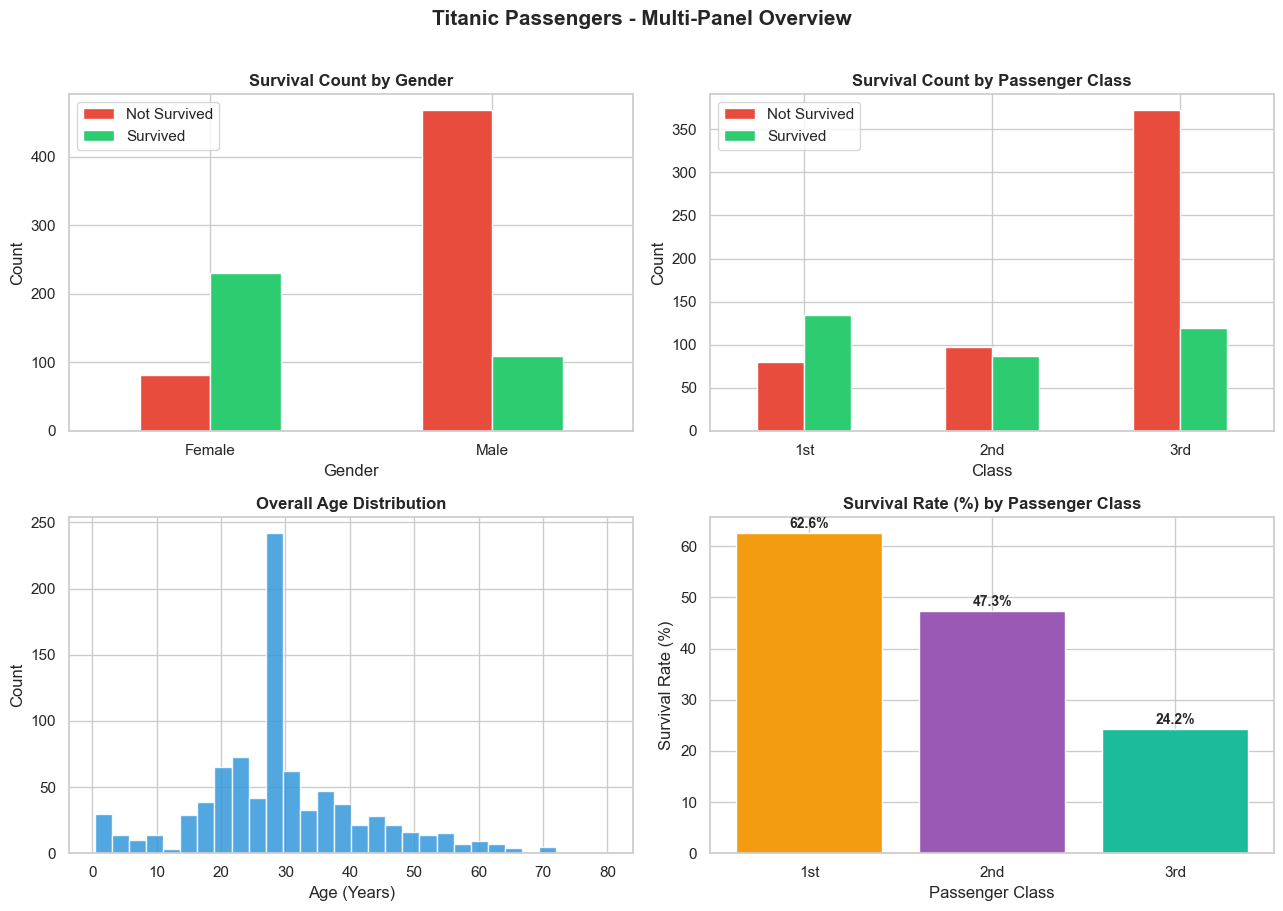

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Titanic Passengers - Multi-Panel Overview', fontsize=15, fontweight='bold', y=1.01)

# Panel 1: Survival by Sex
sex_surv = df.groupby(['sex','survived']).size().unstack()
sex_surv.plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0,0].set_title('Survival Count by Gender', fontweight='bold')
axes[0,0].set_xlabel('Gender'); axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Female','Male'], rotation=0)
axes[0,0].legend(['Not Survived','Survived'])

# Panel 2: Survival by Passenger Class
class_surv = df.groupby(['pclass','survived']).size().unstack()
class_surv.plot(kind='bar', ax=axes[0,1], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0,1].set_title('Survival Count by Passenger Class', fontweight='bold')
axes[0,1].set_xlabel('Class'); axes[0,1].set_ylabel('Count')
axes[0,1].set_xticklabels(['1st','2nd','3rd'], rotation=0)
axes[0,1].legend(['Not Survived','Survived'])

# Panel 3: Age Distribution
axes[1,0].hist(df['age'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[1,0].set_title('Overall Age Distribution', fontweight='bold')
axes[1,0].set_xlabel('Age (Years)'); axes[1,0].set_ylabel('Count')

# Panel 4: Survival Rate by Class (%)
surv_rate = df.groupby('pclass')['survived'].mean() * 100
bars = axes[1,1].bar(surv_rate.index, surv_rate.values, color=['#f39c12','#9b59b6','#1abc9c'], edgecolor='white')
axes[1,1].set_title('Survival Rate (%) by Passenger Class', fontweight='bold')
axes[1,1].set_xlabel('Passenger Class'); axes[1,1].set_ylabel('Survival Rate (%)')
axes[1,1].set_xticks([1,2,3]); axes[1,1].set_xticklabels(['1st','2nd','3rd'])
for bar in bars:
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_subplot_grid.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The multi-panel view reveals the three main axes of survival inequality: gender (females survived at ~74% vs males at ~19%), class (1st class ~63%, 2nd ~47%, 3rd ~24%), and age (young adult peak at 20–35). These panels together underscore that survival was far from random — it was heavily shaped by social privilege.

## Section 4 - Seaborn Statistical Charts
### Chart 6 - Box Plot: Age by Class and Survival

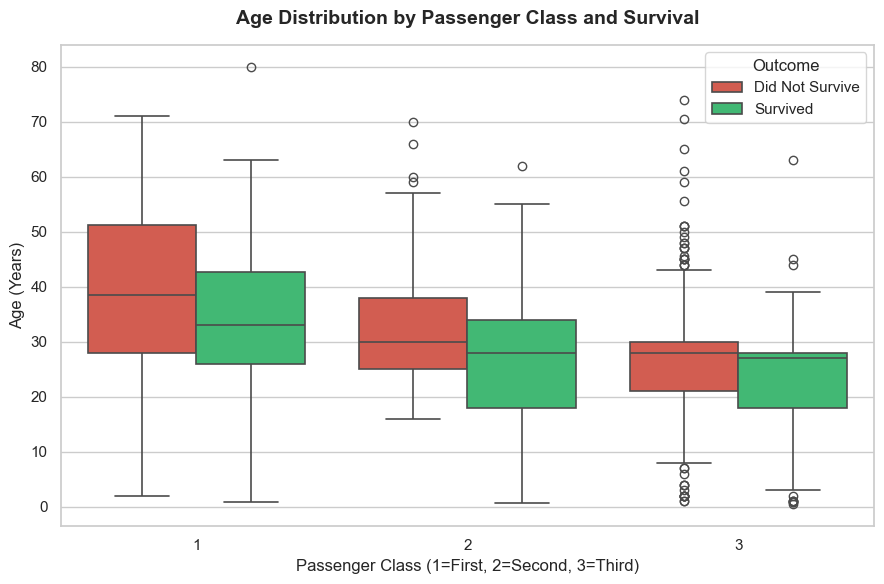

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(data=df, x='pclass', y='age', hue='survived',
            palette={0:'#e74c3c', 1:'#2ecc71'}, ax=ax, linewidth=1.2)

ax.set_title('Age Distribution by Passenger Class and Survival', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Passenger Class (1=First, 2=Second, 3=Third)', fontsize=12)
ax.set_ylabel('Age (Years)', fontsize=12)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Did Not Survive', 'Survived'], fontsize=11, title='Outcome')

plt.tight_layout()
plt.savefig('chart6_seaborn_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** First-class survivors had a notably higher median age (~37) compared to third-class survivors (~24), reflecting the demographic profile of wealthy travellers. The box plot also reveals several high-age outliers, particularly in first class. In third class, the age spread of non-survivors is wide (teens to elderly), suggesting that age alone offered little protection without the advantage of class.

### Chart 7 - Pair Plot: Numerical Features by Survival

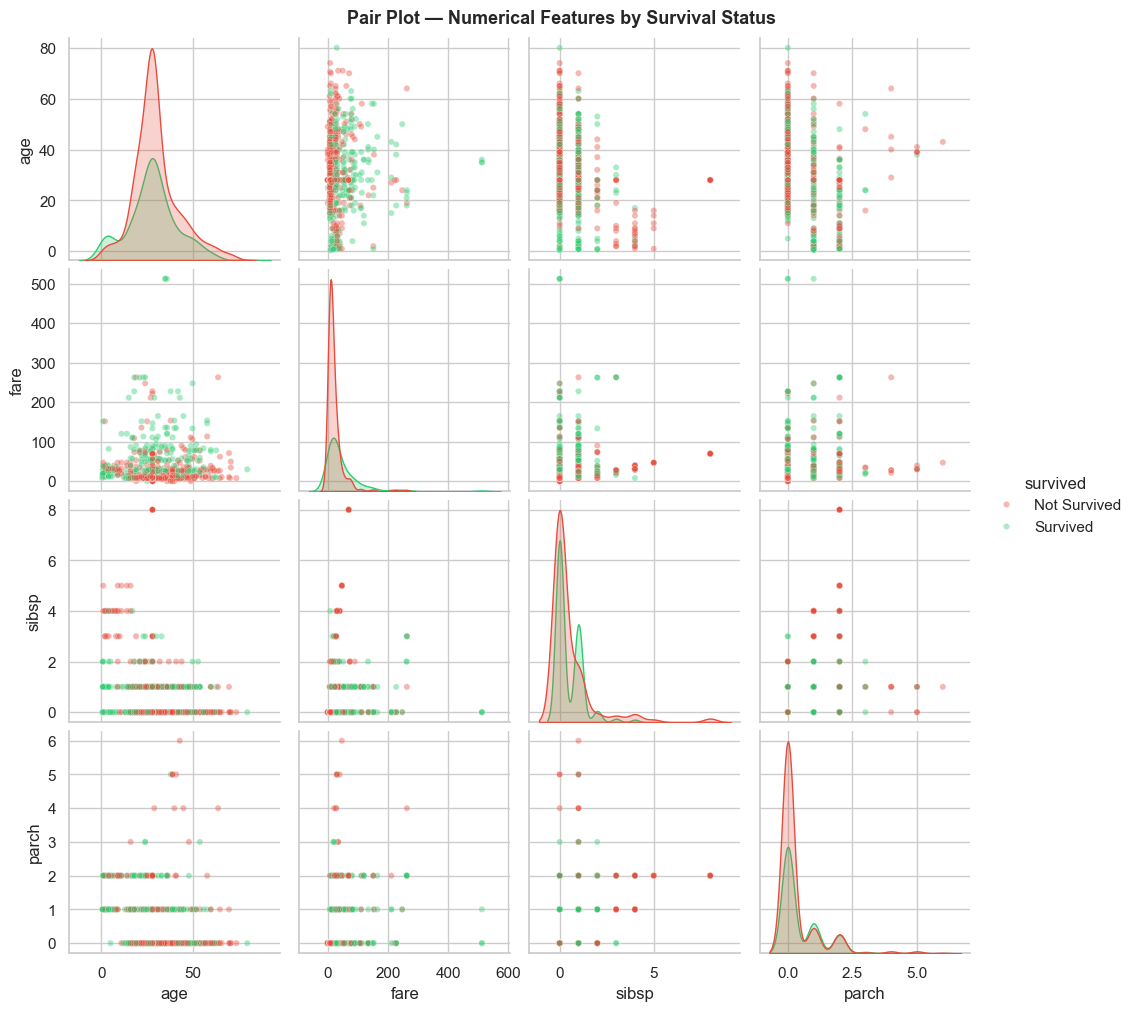

In [21]:
pair_cols = df[['age','fare','sibsp','parch','survived']].copy()
pair_cols['survived'] = pair_cols['survived'].map({0:'Not Survived', 1:'Survived'})

g = sns.pairplot(pair_cols, hue='survived',
                 palette={'Survived':'#2ecc71','Not Survived':'#e74c3c'},
                 plot_kws={'alpha': 0.4, 's': 20}, diag_kind='kde')
g.figure.suptitle('Pair Plot — Numerical Features by Survival Status', y=1.01, fontsize=13, fontweight='bold')
g.figure.savefig('chart7_seaborn_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:** The pair plot shows that Fare is the variable most visually separable between survivors and non-survivors -
 the green (survived) cluster extends higher on the Fare axis in nearly every panel. Age and Parch show substantial overlap between the two groups, indicating weaker individual predictive power. The fare-survival relationship is the clearest pairwise signal in this dataset.

### Chart 8 - Correlation Heatmap

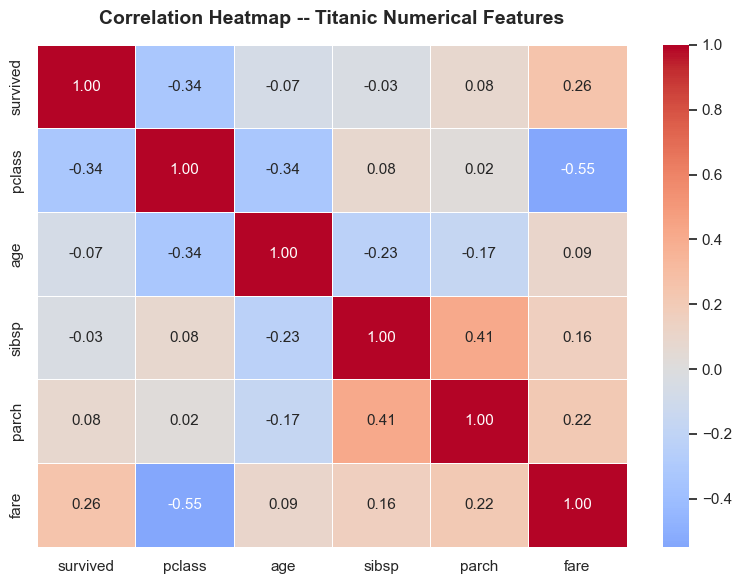

In [85]:
fig, ax = plt.subplots(figsize=(8, 6))

corr_df = df[['survived','pclass','age','sibsp','parch','fare']].copy()
corr = corr_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 11})
ax.set_title('Correlation Heatmap -- Titanic Numerical Features', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart8_seaborn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The heatmap confirms that Pclass is the strongest predictor of survival with a correlation of -0.34 (lower class -> lower survival). Fare correlates positively with survival (+0.26), reinforcing the class-wealth link. Age shows a mild negative correlation (-0.08), and family-size variables (SibSp, Parch) are near-zero, suggesting family composition had limited direct impact on survival probability.

## Section 5 - Interactive Chart (Plotly)
### Chart 9 - Survival Rate by Class and Gender

In [93]:
import plotly.io as pio
pio.renderers.default = "browser"
if  PLOTLY_AVAILABLE:
    surv_gender_class = df.groupby(['pclass','sex'])['survived'].mean().reset_index()
    surv_gender_class['survival_pct'] = (surv_gender_class['survived'] * 100).round(1)
    surv_gender_class['class_label'] = surv_gender_class['pclass'].map({1:'1st Class', 2:'2nd Class', 3:'3rd Class'})

    fig = px.bar(
        surv_gender_class,
        x='class_label', y='survival_pct', color='sex',
        barmode='group',
        color_discrete_map={'female':'#9b59b6','male':'#3498db'},
        labels={'survival_pct': 'Survival Rate (%)', 'class_label': 'Passenger Class', 'sex': 'Gender'},
        title='Interactive: Survival Rate (%) by Passenger Class and Gender',
        hover_data={'survival_pct': ':.1f', 'class_label': True, 'sex': True}
    )
    fig.update_layout(title_font_size=15, plot_bgcolor='white', yaxis_range=[0, 105])
    fig.show()
    
else:
    pivot = df.groupby(['pclass','sex'])['survived'].mean().unstack() * 100
    x = np.arange(3)
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 6))
    bars1 = ax.bar(x - width/2, pivot['female'], width, label='Female', color='#9b59b6', alpha=0.85)
    bars2 = ax.bar(x + width/2, pivot['male'], width, label='Male', color='#3498db', alpha=0.85)
    ax.set_title('Survival Rate (%) by Passenger Class and Gender', fontsize=14, fontweight='bold')
    ax.set_xlabel('Passenger Class', fontsize=12)
    ax.set_ylabel('Survival Rate (%)', fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(['1st Class','2nd Class','3rd Class'])
    ax.legend(fontsize=11); ax.set_ylim(0, 105)
    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{bar.get_height():.1f}%', ha='center', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{bar.get_height():.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('chart9_plotly_style.png', dpi=150, bbox_inches='tight')
    plt.show()


**Insight:** This chart powerfully illustrates the intersection of gender and class. First-class females had the highest survival rate (~97%), while third-class males had the lowest (~15%). Even among women, class mattered: third-class females survived at ~50%, compared to ~97% for first-class females. This confirms that both gender and socioeconomic status independently shaped survival outcomes.

## Section 6 - Insight Summary

### Key Finding 1 - Gender Was the Single Strongest Survival Predictor
Female passengers survived at **~74%** compared to just **~19%** for males. This directly reflects the 'women and children first' evacuation protocol enforced by the crew. *(Reference: Chart 5 — Subplot Panel 1)*

### Key Finding 2 - Passenger Class Determined Access to Lifeboats
First-class passengers had a **~63% survival rate** vs 24% for third-class. Cabin location (upper decks for first class) and crew priority meant wealthier passengers reached the lifeboats first. *(Reference: Chart 5 — Panel 4 & Chart 6)*

### Key Finding 3 - Fare Was a Better Survival Signal Than Age
The correlation heatmap showed Fare (+0.26) correlated more strongly with survival than Age (-0.08). The scatter plot (Chart 4) visually confirmed that high-fare passengers cluster among survivors. *(Reference: Chart 8, Chart 4)*

### Key Finding 4 - Combined Disadvantage (3rd Class Male) Was Devastating
Third-class males faced the worst odds (~15% survival rate). Neither class nor gender alone tells the full story — their intersection reveals extreme vulnerability. *(Reference: Chart 9)*

### Key Finding 5 - Most Passengers Were 20–35 Years Old
The age histogram (Chart 2) shows a strong concentration of passengers in the 20–35 age range. Young children showed relatively better survival odds, but adult age did not meaningfully differentiate survivors from non-survivors. *(Reference: Chart 2)*

## Section 7 - Conclusion

### Most Important Finding
**Survival on the Titanic was not a matter of chance — it was a function of social privilege.** Gender and passenger class, acting together, determined who reached the lifeboats. A first-class woman had a near-certain chance of survival; a third-class man had roughly a 1-in-7 chance. Fare, as a proxy for wealth, was more predictive of survival than biological age, reinforcing this conclusion.

### Limitations
- The dataset captures only ~71% of the actual 1,317 passengers aboard (891 records). Survivors may be over- or under-represented.
- Age imputation (177 missing values filled with median) may have smoothed out genuine age effects.
- Cabin number data is largely missing, preventing cabin-location-based analysis which would be highly informative.
- The dataset is a static historical snapshot with no time dimension, so the sequence of evacuation events cannot be modelled.

